In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

X_train = pd.read_csv("../data/X_train.csv", index_col=0, parse_dates=True)
X_test  = pd.read_csv("../data/X_test.csv", index_col=0, parse_dates=True)
y_train = pd.read_csv("../data/y_train.csv", index_col=0, parse_dates=True).squeeze()
y_test  = pd.read_csv("../data/y_test.csv", index_col=0, parse_dates=True).squeeze()

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(948, 12) (238, 12)
Target
1    505
0    443
Name: count, dtype: int64


In [ ]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train) #what does .fit do? it is basically how we train the model, .fit(input,output), we tell
                            #the model that here is the input and the correct output, learn the relationship between them
                            
print("Training complete")

Training complete


n_estimators=100: no of trees
max_depth=4: no of decisions a tree can make
learning_rate=0.05: how much power a tree has
random_state=42: we fix the random set of rows that each model gets everytime to make results reproducible.

In [5]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy: ",accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy:  0.5672268907563025

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.62      0.55       102
           1       0.65      0.53      0.58       136

    accuracy                           0.57       238
   macro avg       0.57      0.57      0.57       238
weighted avg       0.58      0.57      0.57       238



What does this classification report say? 

Precision — of all days model predicted UP, what fraction actually went UP?
High precision = when model says buy, it's usually right. Few false alarms.
Recall — of all days that actually went UP, what fraction did model catch?
High recall = model catches most up moves, but might have more false alarms.
F1 Score — single number that balances both:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

Why do we need both? Because a model can cheat each metric individually:

Predict UP every single day → perfect recall, terrible precision
Predict UP only on the single most obvious day → perfect precision, terrible recall

F1 punishes both extremes.



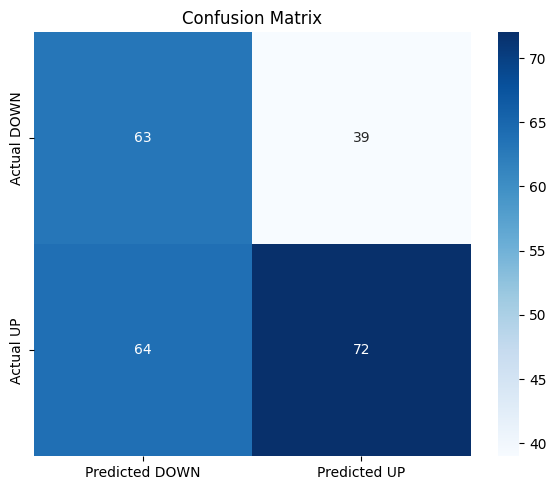

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted DOWN", "Predicted UP"],
            yticklabels=["Actual DOWN", "Actual UP"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

What do the 4 cells in the confusion matrix represent?  they represent all 4 types of cases possible for us
Which cell represents the model predicting UP but the stock actually went DOWN? Why is this the most costly error in a trading context? this is the most costly error as it predicted up and say we inveted money but market actually went down so we lost money.


True Negative — model said DOWN, stock actually went DOWN. Correct.
True Positive — model said UP, stock actually went UP. Correct.
False Positive — model said UP, stock actually went DOWN. You bought, lost money. Most costly.
False Negative — model said DOWN, stock actually went UP. You missed a profit. Less painful.

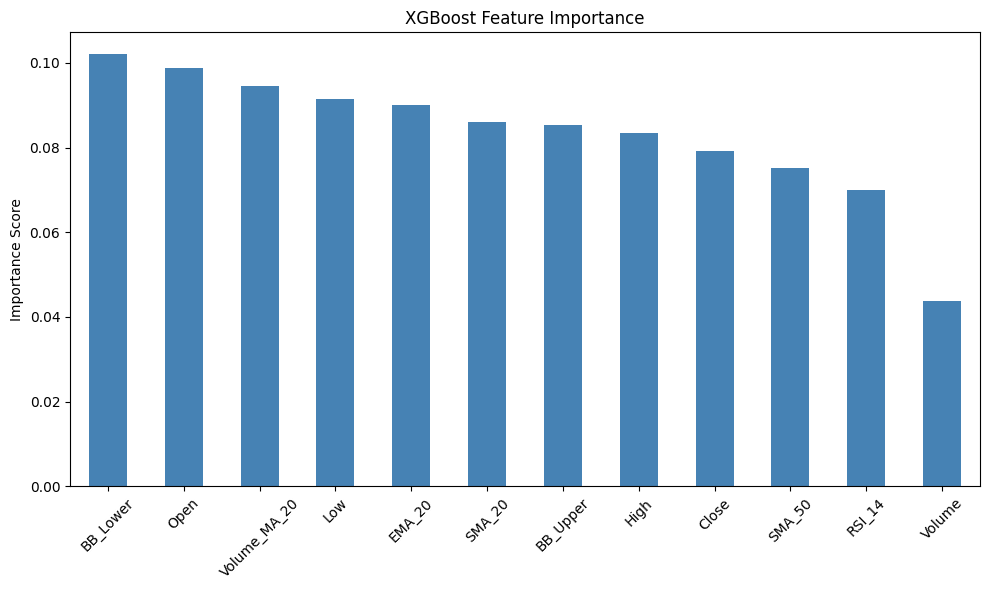

BB_Lower        0.102114
Open            0.098915
Volume_MA_20    0.094614
Low             0.091426
EMA_20          0.090053
SMA_20          0.085968
BB_Upper        0.085284
High            0.083386
Close           0.079234
SMA_50          0.075141
RSI_14          0.070039
Volume          0.043826
dtype: float32


In [7]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind="bar", color="steelblue")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(importance)

Which feature is most important? Does that surprise you? BB_lower is most important honestly that does surprise me, I would have assumed it would be either RSI or close value.
Which feature is least important? Volume is least important
Does anything in this chart change how you think about the features we engineered? yeah I though RSI would be very important as that is something we speicfically calculated and were telling overbought underbought from that

BB_Lower being most important actually makes sense when you think about it. Remember what BB_Lower captures — it's the lower volatility boundary. When price approaches or breaks below BB_Lower it's a statistically unusual event that historically precedes a directional move. XGBoost found this to be the most predictive signal in your data.

BB_Lower most important — captures statistically unusual price events near volatility boundary. Raw volume least important — confirms that volume needs context to be meaningful.

In [8]:
#saving model

import pickle
with open("../data/model.pkl", "wb") as f:
    pickle.dump(model ,f)    